# Do symbol hints help model agreement checks? — Candidate-Signature Consensus (CSC)

**Artifact:** iteration-4 experiment T6-P from a project on *gold-free* quality metrics for natural-language → first-order-logic (NL→FOL) translation.

**The question.** One cheap way to check a candidate FOL translation without a gold formula is to ask other models (*peers*) to translate the same sentence and test, with the z3 solver, whether they agree. Free-form peers pick their own predicate names, so a correct candidate often "disagrees" only because it uses different vocabulary. **Candidate-Signature Consensus (CSC)** gives each peer the candidate's *own symbol list* (predicate/constant names and arities). Agreement then becomes *exact*, case-insensitive z3 equivalence with no vocabulary aligner. The risk is **anchoring**: a peer may copy a wrong symbol from the list and so endorse an error.

Score orientation: **higher = more likely an error**, with a flag at `c > 0.5`:

`c_csc = 1 − (#peers exactly equivalent to the candidate) / (#peers with a parseable formula)`

**What actually ran (deviation D-BUDGET).** The OpenRouter budget for the whole run ran out before the first CSC peer call, so **no API-model CSC peers exist**. The pre-registered gates are *untested*, not failed. This notebook runs the zero-cost arms that the artifact did score:

| arm | peers | cue |
|---|---|---|
| **LOCAL2** (secondary) | qwen2.5-1.5b + gemma-2-2b (local, llama.cpp) | the real CSC prompt with the row's own symbol list, **and** with its base's list (→ Δ-anchor) |
| **SIGPROXY** | exp-7 outputs of deepseek-v3.2 / phi-4 / gpt-4.1-mini (+qwen3-235b for K4) | a closed template signature (R_COMP sentences only) |
| **FREE3** | the same 3 API families, **uncued** | none (baseline) |

**What this notebook does.** It (1) shows `method.py`, the artifact's stage orchestrator, and (2) runs the CPU stages that orchestrator dispatches to: `csc_lib` scoring, `csc_score` task building, `csc_typing` same-vocabulary typed repair, and the `csc_analysis` anchoring / false-alarm / Δ-anchor tables. They run on a curated PERTURB subset: gold-derived bases plus mutants with known error operators and meaning-preserving controls. The peer formulas are the stored outputs, so no model is called.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install (z3 version = the artifact's pin)
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, scipy, scikit-learn, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- method.py imports (original block) ---
import argparse
import asyncio
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- csc_lib.py imports (original block) ---
import hashlib
import itertools
import json
import random
import re

# --- csc_score.py / csc_typing.py / csc_analysis.py imports (original blocks) ---
import csv
import math
import multiprocessing as mp
import os
import signal
import time
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np

# --- notebook additions: materialising files + results summary / plots ---
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-4/experiment-10/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if hasattr(v, '__len__') else v) for k, v in data.items()})
print(json.dumps(data["meta"], indent=1))

{'meta': 6, 'perturb_view': 92, 'free3_peers': 5, 'rcomp_sig_view': 8, 'peers_local2': 25, 'reference_scores': 100, 'prompt_fewshot_v1': 3, 'support_modules': 7}
{
 "source_artifact": "experiment-10 (iteration 4, T6-P, Candidate-Signature Consensus)",
 "local2_bases": [
  "68a12f5080ef6661",
  "0c6e5b7b57032592",
  "6cf07d704ad11929"
 ],
 "rcomp_bases": [
  "c6210475cba01b00",
  "efdb353bf0d1a008"
 ],
 "n_perturb_rows": 92,
 "n_sig_rows": 8,
 "n_local2_peer_sets": 25
}


### What is in `mini_demo_data.json`

A curated slice of the artifact's **PERTURB** meta-evaluation set, with the stored peer outputs its scoring stage reads:

* `perturb_view`: 92 rows from 5 bases. 3 bases are dataset-E sentences that were also in the LOCAL2 arm; 2 are long R_COMP sentences with SIGPROXY peers. Each base has its unmutated **BASE** row (label-certain correct), its **mutants** (`y = 1`, each with a known error operator such as `NEG`, `ADD_FOREIGN`, `MEANING_RENAME`, `SWAP`, …) and its meaning-preserving **controls** (`y = 0`: `RENAME_SYN`, `RENAME_NONCE`, `CONTRAPOSITIVE`, `REORDER_COMMUTE`, …).
* `rcomp_sig_view`: the exp-7 signature-cued outputs of the 4 peer families for the R_COMP sentences. These are the SIGPROXY peers.
* `free3_peers`: uncued outputs of the same 3 families. `peers_local2`: LOCAL2 peer outputs, cued with each row's signature.
* `reference_scores`: the artifact's own stage-6 scores for these rows, used below to check that the notebook reproduces them.
* `prompt_fewshot_v1` and `support_modules`: the few-shot prompt, and the small pure-Python modules `csc_lib` imports (the dataset-E FOL parser, the z3 equivalence wrapper, `repair_census`, and the uncued `consensus_lib`). The next cell writes them to disk so the original imports work unchanged.

## Configuration

Every tunable knob is set here. The values are sized for the mini file, and the artifact's full-run values are given in the comments. With the full `perturb_view.jsonl` (5,402 rows) and `rcomp_sig_view.jsonl` (2,210 SIG rows), the original stage 6 took minutes on a many-core machine.

In [5]:
N_BASES = 5            # bases taken from the mini file (each brings its BASE row + all mutants + controls); max 5 here. Original: all 300 bases
MAX_SIG_TASKS = 8      # exp-7 SIG rows scored as candidates (original: all 2,210)
Z3_MS = 2000           # z3 timeout per equivalence check, ms (original: 2000)
GRADED_CAP_S = 90      # wall-clock cap per graded-consensus call, s (original: 90)
BUDGET_S = 6.0         # typed-repair search budget per (mutant, target), s (original: 6.0)
N_TYPING_JOBS = 10000  # typed-repair jobs, sampled like the original `--mini N`; >= #jobs runs them all (original: all ~11k jobs)
DRY_RUN = True         # method.py stage commands are only logged: the stage scripts / API budget are not available here

### Materialise the artifact layout

The original scripts read `data/*.jsonl` and import `csc_lib` together with its vendored helpers from `src/`. This cell writes the loaded `data` into that layout under `./csc_demo/`, so the code below runs with its original paths. It also clears `results/`, because the scoring stage resumes by key and a re-run should start fresh.

In [6]:
DEMO_ROOT = Path("csc_demo").resolve()
DEMO_SRC = DEMO_ROOT / "src"
shutil.rmtree(DEMO_ROOT / "results", ignore_errors=True)
for rel, src_text in data["support_modules"].items():
    if rel == "csc_lib.py":
        continue  # csc_lib's code is shown and executed in the cells below
    p = DEMO_SRC / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(src_text)

_m = data["meta"]
BASE_ORDER = [b for pair in zip(_m["local2_bases"], _m["rcomp_bases"] + [None]) for b in pair if b]  # E, R, E, R, E
sel_bases = set(BASE_ORDER[:N_BASES])
view_rows = [r for r in data["perturb_view"] if r["base_item_id"] in sel_bases]
sel_sids = {r["sentence_id"] for r in view_rows}
sel_pairs = {(r["text"], r["sig_key"]) for r in view_rows}

def _write_jl(p, rows):
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))

_write_jl(DEMO_ROOT / "data" / "perturb_view.jsonl", view_rows)
_write_jl(DEMO_ROOT / "data" / "rcomp_sig_view.jsonl", [r for r in data["rcomp_sig_view"] if r["sentence_id"] in sel_sids])
_write_jl(DEMO_ROOT / "data" / "peers_local2.jsonl", [u for u in data["peers_local2"] if (u["text"], u["sig_key"]) in sel_pairs])
(DEMO_ROOT / "data" / "free3_peers.json").write_text(json.dumps({k: v for k, v in data["free3_peers"].items() if k in sel_sids}, ensure_ascii=False))
(DEMO_ROOT / "data" / "prompts").mkdir(parents=True, exist_ok=True)
(DEMO_ROOT / "data" / "prompts" / "fewshot_v1.txt").write_text(json.dumps(data["prompt_fewshot_v1"], ensure_ascii=False, indent=1))
print(f"{len(view_rows)} PERTURB rows from {len(sel_bases)} bases:",
      dict(Counter(r['fold'] for r in view_rows)), "| E/R_COMP:", dict(Counter('RCOMP' if r['is_rcomp'] else 'E' for r in view_rows)))

92 PERTURB rows from 5 bases: {'PERTURB': 73, 'PERTURB_CONTROL': 14, 'BASE': 5} | E/R_COMP: {'E': 54, 'RCOMP': 38}


## 1. `method.py`: the stage orchestrator (original script)

The artifact's entry point runs named stages in order. Each stage is a separate script in `src/`. The API stages (`pilot`, `peers`) run only when a 1-token probe shows the OpenRouter key still has budget. In the real run the probe returned `403 aii_run_budget_exhausted`, so both were skipped (deviation **D-BUDGET**) and every `$0` stage ran.

Notebook changes, kept minimal: `ROOT` points to `./csc_demo`; `run()` and `key_has_budget()` respect `DRY_RUN`, because the stage scripts and the API client are not shipped with the notebook; `main()` takes `argv` instead of reading the kernel's `sys.argv`. Sections 2–5 below then run the CPU stages that matter (`score`, `typing`, `analysis`) inline.

In [7]:
"""Orchestrator: Candidate-Signature Consensus (CSC) on PERTURB and R_COMP (iteration 4, T6-P).

Stages (comma-separated with --stage, or 'all'):
  views     STAGE 1  data views, signatures, sig_sharing.csv, firewalled FREE view, FREE3 peers      (CPU, $0)
  tests     unit tests (tests/test_csc_lib.py) - must pass before any API call                      (CPU, $0)
  pilot     STAGE 3  30 signatures x 4 models; compliance, usage, projection, prompt choice          (API ~$0.12)
  prereg    STAGE 4  freeze results/prereg_csc_P.json (+sha256); never overwritten                  (CPU)
  peers     STAGE 5  CSC peer sweeps perturb_E -> free -> perturb_R -> sig -> retest                 (API ~$3.4)
  local     LOCAL2 secondary local-peer arm (llama.cpp, CPU)                                          ($0)
  score     STAGE 6  CSC / SIGPROXY / FREE3 scores (+ --local LOCAL2 scores)                         (CPU)
  typing    STAGE 7  same-vocabulary typed-repair searches                                          (CPU)
  analysis  STAGE 7  all tables (verifies the prereg sha256 first), tables.md, deviations            (CPU)
  manifest  job manifest for the peer sweep + firewall record                                        (CPU)
  output    STAGE 9  perturb_csc_scores.jsonl, csc_rcomp_sig_scores.jsonl, method_out.json            (CPU)
  rederive  independent re-derivation (tests/rederive.py)                                              (CPU)
'all' runs every $0 stage in order and the API stages only when the OpenRouter key has budget (1-token probe).
"""
ROOT = DEMO_ROOT  # notebook: was Path(__file__).resolve().parent
PY = sys.executable
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")


def run(args: list[str], timeout: int = 7200) -> None:
    logger.info("$ " + " ".join(args))
    if DRY_RUN:  # notebook: the stage scripts are not shipped; the CPU stages run inline in the sections below
        return
    r = subprocess.run(args, cwd=ROOT, timeout=timeout)
    if r.returncode != 0:
        raise RuntimeError(f"stage failed ({r.returncode}): {' '.join(args)}")


def key_has_budget() -> bool:
    if DRY_RUN:  # notebook: no OpenRouter client / key here (the real probe returned 403 aii_run_budget_exhausted)
        logger.info("key probe: DRY_RUN (no API client in the notebook) -> no budget")
        return False
    sys.path.insert(0, str(ROOT / "src"))
    import or_client
    try:
        ok, msg = asyncio.run(or_client.probe())
    except Exception as ex:  # noqa: BLE001 - network errors mean 'no budget now'
        ok, msg = False, f"{type(ex).__name__}: {ex}"
    logger.info(f"key probe: {msg}")
    return ok


STAGES = {
    "views": [[PY, "src/views.py"]],
    "tests": [[PY, "-m", "pytest", "-q", "tests/test_csc_lib.py", "-p", "no:cacheprovider"]],
    "pilot": [[PY, "src/peers_run.py", "pilot"]],
    "prereg": [[PY, "src/csc_prereg.py"]],
    "peers": [[PY, "src/peers_run.py", "all"]],
    "local": [[PY, "src/local_peers.py"]],
    "score": [[PY, "src/csc_score.py"], [PY, "src/csc_score.py", "--local"]],
    "typing": [[PY, "src/csc_typing.py", "--which", "oracle,csc,proxy,free3"]],
    "analysis": [[PY, "src/csc_analysis.py"], [PY, "src/csc_tables.py"]],
    "manifest": [[PY, "src/csc_manifest.py"]],
    "output": [[PY, "src/csc_output.py"]],
    "rederive": [[PY, "tests/rederive.py"]],
}
ORDER = ["views", "tests", "pilot", "prereg", "peers", "local", "score", "typing", "manifest", "analysis", "output", "rederive"]
API = {"pilot", "peers"}


@logger.catch(reraise=True)
def main(argv=None) -> None:  # notebook: argv instead of the kernel's sys.argv
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="all")
    a = ap.parse_args(argv)
    stages = ORDER if a.stage == "all" else a.stage.split(",")
    api_ok = None
    for st in stages:
        if st not in STAGES:
            raise SystemExit(f"unknown stage {st}; choose from {ORDER}")
        if st in API:
            if api_ok is None:
                api_ok = key_has_budget()
            if not api_ok:
                logger.warning(f"skipping {st}: OpenRouter key has no budget (deviation D-BUDGET)")
                continue
        for cmd in STAGES[st]:
            run(cmd)
    logger.info("done")


main(["--stage", "all"])

13:22:43|INFO   |$ python src/views.py


13:22:43|INFO   |$ python -m pytest -q tests/test_csc_lib.py -p no:cacheprovider


13:22:43|INFO   |key probe: DRY_RUN (no API client in the notebook) -> no budget


13:22:43|WARNING|skipping pilot: OpenRouter key has no budget (deviation D-BUDGET)


13:22:43|INFO   |$ python src/csc_prereg.py


...

13:22:43|INFO   |$ python src/csc_analysis.py


13:22:43|INFO   |$ python src/csc_tables.py


13:22:43|INFO   |$ python src/csc_output.py


13:22:43|INFO   |$ python tests/rederive.py


13:22:43|INFO   |done


## 2. `csc_lib`: the CSC metric library (original code, verbatim)

`method.py` dispatches all scoring to `src/csc_lib.py`. Its docstring states exactly what is measured:

```text
csc_lib: Candidate-Signature Consensus (CSC) for gold-free NL->FOL faithfulness (iteration 4, T6-P).

WHAT CSC MEASURES. Peers from k = 3 other model families translate the SAME sentence after being shown the
CANDIDATE's own symbol list (predicate and constant names with arities, shuffled deterministically). A peer agrees
when its formula is z3-equivalent to the candidate with NO aligner: symbol names are matched case-insensitively
(key = (lower(name), arity)) and nothing else. Because the peers are cued with the candidate's vocabulary, the
rename/vocabulary problem of free consensus disappears by construction: an equivalent translation in the same
vocabulary is exact-equivalent. The price is ANCHORING: a peer may copy a wrong symbol from the list (a foreign
conjunct, a wrong-meaning predicate) and thereby endorse an error. This library measures both sides.

Orientation everywhere: HIGHER score = MORE LIKELY ERROR.

  c_csc        = 1 - (#peers exact-equivalent to the candidate) / (#peers with a parseable formula).
                 z3 UNKNOWN (2 s timeout) counts as NOT equivalent and is recorded in n_unknown.
                 < 2 parseable peers -> 0.5 with status 'csc_insufficient_peers'.
                 Unparseable candidate -> 1.0 with status 'UNPARSEABLE' (coverage view; never silently dropped).
  c_csc_multi  = the same, but peer p also endorses when its SECOND reading (alt_fol) is equivalent to the candidate
                 AND another peer q != p produced that reading too (fol or alt) - a corroborated alternative reading.
  c_csc_graded = exp-5 / exp-8 peer_text.graded_consensus over claim units with the IDENTITY symbol map
                 (1 - F1(support, coverage)); unit entailment by the finite-model refuter then z3.
Blind spots (stated): errors every cued peer copies from the list (anchoring; measured on PERTURB ADD_FOREIGN /
MEANING_RENAME); errors shared by the peers independently of the cue; readings no peer produces.
Cost: k API calls per unique (sentence, signature); z3 CPU seconds per candidate (MARGINAL cost).
```

The cells below are the library's code, copied section by section. The only change is the first line of the path header, which now points to the materialised `./csc_demo/src`. It still imports the dataset-E parser (`peer_text` / `fol`) and `repair_census` (atoms, symbols, random-model fingerprints `fp`, and typed edits).

In [8]:
import hashlib
import itertools
import json
import random
import re
import sys
from pathlib import Path

SRC = DEMO_SRC  # notebook: was Path(__file__).resolve().parent (the artifact's src/)
ROOT = SRC.parent
V8 = SRC / "vendor_x8"
if str(V8) not in sys.path:
    sys.path.insert(0, str(V8))
import peer_text as PT  # noqa: E402  (installs the dataset-E parser as module 'fol'; adds vendor_c / vendor_a)
import fol as EFOL  # noqa: E402  (== vendor_e.fol, the dataset-E parser)
sys.path.insert(0, str(V8 / "vendor_c"))
import repair_census as RC  # noqa: E402  (vendor_c: atoms, symbols, fp, edits, search)

PROMPT_PATH = ROOT / "data" / "prompts" / "fewshot_v1.txt"
PEERS = [("deepseek/deepseek-v3.2", "deepseek", {"reasoning": {"enabled": False}}),
         ("microsoft/phi-4", "microsoft", {}),
         ("openai/gpt-4.1-mini", "openai", {}),
         ("qwen/qwen3-235b-a22b-2507", "qwen", {})]
PEER_MODELS = [p[0] for p in PEERS]
PEER_FAMILY = {p[0]: p[1] for p in PEERS}
PEER_EXTRA = {p[0]: p[2] for p in PEERS}
BLOCK_TEMPLATE = ("Symbols from another translation of this sentence (name/arity, random order): {items}. "
                  "Use a listed symbol wherever its name fits what the sentence says, and keep its arity. "
                  "If part of the sentence is not covered by any listed symbol, introduce a new symbol. "
                  "You need not use every listed symbol. The list is not a translation: translate the sentence "
                  "itself. Return JSON {{\"fol\": <formula>, \"alt_fol\": <a formula for a second legitimate "
                  "reading, or null>}}.")
V1B_PREFIX = "For this sentence, a symbol list IS given: "
Z3_MS = 2000


def block_template_sha256() -> str:
    return hashlib.sha256(BLOCK_TEMPLATE.encode()).hexdigest()

### 2a. Signatures

A candidate's **signature** lists its predicates (name, arity) and constants (name, 0), excluding bound variables. This list is what a CSC peer receives. `sig_key` hashes the lower-cased signature, so two rows with the same key share one peer call.

In [9]:
# ============================================================================================ parse / signature
def parse(s: str | None):
    """Dataset-E parser -> AST or None (unparseable)."""
    return PT.parse_fol(s)


def _bound(e, acc=None):
    return RC.bound_vars(e, acc)


def extract_signature_ast(e) -> list[tuple[str, int]]:
    """Symbols of a parsed formula: predicates (name, arity >= 0 for propositional atoms) and constants (name, 0);
    bound variables excluded. Sorted by (lower(name), arity, name); one entry per lowercase key (first spelling wins)."""
    P, C = RC.symbols(e)
    items = sorted(set(P) | {(c, 0) for c in C}, key=lambda t: (t[0].lower(), t[1], t[0]))
    out, seen = [], set()
    for n, a in items:
        k = (n.lower(), a)
        if k not in seen:
            seen.add(k)
            out.append((n, a))
    return out


def extract_signature(fol: str) -> list[tuple[str, int]]:
    """(name, arity) list of the formula's predicates and constants (arity 0), variables excluded; [] if unparseable."""
    e = parse(fol)
    return [] if e is None else extract_signature_ast(e)


def sig_lower(sig) -> list[tuple[str, int]]:
    return sorted({(n.lower(), a) for n, a in sig})


def sig_string(sig) -> str:
    return "|".join(f"{n}/{a}" for n, a in sig_lower(sig))


def sig_key(sig) -> str:
    return hashlib.sha1(sig_string(sig).encode()).hexdigest()[:16]

### 2b. The CSC prompt

The peer prompt is the unchanged dataset-E few-shot prompt, followed by a **symbol block**: the candidate's symbols in a deterministic shuffled order (seeded by the sentence and signature). The block tells the peer to reuse listed symbols where they fit, to introduce new ones for uncovered content, and to return `{"fol", "alt_fol"}`.

In [10]:
# ============================================================================================ prompt
_PROMPT_CACHE: dict = {}


def _prompt() -> dict:
    if "p" not in _PROMPT_CACHE:
        _PROMPT_CACHE["p"] = json.loads(PROMPT_PATH.read_text())
    return _PROMPT_CACHE["p"]


def symbols_block(text: str, sig, variant: str = "v1") -> str:
    """The appended CSC block; the list order is a deterministic shuffle seeded by sha1(text | canonical signature)."""
    items = [f"{n}/{a}" for n, a in sorted(sig, key=lambda t: (t[0].lower(), t[1], t[0]))]
    rng = random.Random(int(hashlib.sha1((text + "|" + sig_string(sig)).encode()).hexdigest(), 16))
    rng.shuffle(items)
    b = BLOCK_TEMPLATE.format(items=", ".join(items))
    return (V1B_PREFIX + b) if variant == "v1b" else b


def csc_prompt(text: str, signature, variant: str = "v1") -> list[dict]:
    """Messages: the byte-identical dataset-E few-shot prompt (system + 6 exemplars) + the user turn
    'Sentence: <text>' followed by a blank line and the symbols block."""
    pr = _prompt()
    user = pr["user_template"].replace("{sentence}", text) + "\n\n" + symbols_block(text, signature, variant)
    return [{"role": "system", "content": pr["system"]}] + list(pr["exemplars"]) + [{"role": "user", "content": user}]


def free_prompt(text: str) -> list[dict]:
    pr = _prompt()
    return [{"role": "system", "content": pr["system"]}] + list(pr["exemplars"]) + \
        [{"role": "user", "content": pr["user_template"].replace("{sentence}", text)}]

### 2c. Parsing peer output

The parser tries, in order: a JSON object with a `fol` field, then a `FOL:` line, then a single bare line that parses as a formula. Anything else is a `fail`. Failures are counted, never dropped.

In [11]:
# ============================================================================================ peer output parsing
_FENCE = re.compile(r"```(?:json)?", re.I)


def _clean_formula(s):
    if s is None:
        return None
    if not isinstance(s, str):
        return None
    s = s.strip()
    if s.lower() in ("", "null", "none", "n/a"):
        return None
    if s.startswith("FOL:"):
        s = s[4:].strip()
    return s


def parse_peer(raw: str | None) -> dict:
    """Peer raw output -> {'fol', 'alt_fol', 'format' in {json, fol_line, bare, fail}}.
    (1) first JSON object (```json fences tolerated) with a string 'fol'; (2) a 'FOL:' line (alt = None);
    (3) the whole output if it is a single line that parses as a formula ('bare'); else fail."""
    s = (raw or "").strip()
    if not s:
        return {"fol": None, "alt_fol": None, "format": "fail"}
    t = _FENCE.sub("", s)
    dec = json.JSONDecoder()
    for m in re.finditer(r"\{", t):
        try:
            obj, _ = dec.raw_decode(t[m.start():])
        except json.JSONDecodeError:
            continue
        if isinstance(obj, dict) and isinstance(obj.get("fol"), str) and obj.get("fol").strip():
            return {"fol": _clean_formula(obj.get("fol")), "alt_fol": _clean_formula(obj.get("alt_fol")), "format": "json"}
    for line in s.splitlines():
        if line.strip().startswith("FOL:"):
            return {"fol": line.split("FOL:", 1)[1].strip() or None, "alt_fol": None, "format": "fol_line"}
    lines = [x for x in t.splitlines() if x.strip()]
    if len(lines) == 1 and parse(lines[0].strip()) is not None:
        return {"fol": lines[0].strip(), "alt_fol": None, "format": "bare"}
    return {"fol": None, "alt_fol": None, "format": "fail"}

### 2d. Exact equivalence (no aligner)

Both formulas are parsed, and every predicate and constant name is lower-cased. There are three steps:
1. Identical canonical strings → equivalent.
2. Different random finite-model fingerprints → **not** equivalent. This is sound, because the formulas differ on a concrete model.
3. Otherwise, z3 decides with a 2 s timeout. A timeout returns `None` (UNKNOWN), which is never counted as agreement.

In [12]:
# ============================================================================================ exact equivalence
def lower_ast(e, bv=frozenset()):
    """Lower-case every predicate and constant name (bound variables untouched)."""
    k = e[0]
    if k == "atom":
        return ("atom", e[1].lower(), tuple(x if x in bv else x.lower() for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], lower_ast(e[2], bv | {e[1]}))
    if k == "not":
        return ("not", lower_ast(e[1], bv))
    return (k, lower_ast(e[1], bv), lower_ast(e[2], bv))


def prep(s: str | None):
    """Parse + lowercase -> (ast, canonical string, fingerprint) or None."""
    e = parse(s)
    if e is None:
        return None
    el = lower_ast(e)
    try:
        f = RC.fp(el)
    except RecursionError:
        f = None
    return el, PT.canon(el), f


def eq_prepped(a, b, ms: int = Z3_MS):
    """a, b from prep(). True / False / None (UNKNOWN). Canonical-string identity -> True; different random-model
    fingerprints -> False (sound: they differ on a finite model); else z3 with `ms` timeout."""
    if a is None or b is None:
        return None
    if a[1] == b[1]:
        return True
    if a[2] is not None and b[2] is not None and a[2] != b[2]:
        return False
    try:
        return EFOL.equivalent(a[0], b[0], ms=ms)
    except (Exception,):  # noqa: BLE001 - z3 exceptions / recursion on huge formulas -> UNKNOWN (counted)
        return None


def eq_exact(fa: str, fb: str, ms: int = Z3_MS):
    """Exact (no aligner) case-insensitive z3 equivalence of two formula strings: True / False / None (UNKNOWN or
    unparseable)."""
    return eq_prepped(prep(fa), prep(fb), ms)

### 2e. The scores

* `consensus_score`: binary CSC, `c = 1 − agree/used`. An unparseable candidate gets `c = 1.0` (`UNPARSEABLE`). Fewer than 2 parseable peers gives `c = 0.5` (`csc_insufficient_peers`).
* `csc_multi_score`: a peer's *second reading* (`alt_fol`) can also endorse the candidate, but only when another peer produced that same reading.
* `graded_consensus`: `1 − F1(support, coverage)` over claim units. Support is the share of the candidate's units the peers entail; coverage is the share of the peers' majority units the candidate entails. This is partial credit.
* `peer_majority`: groups peers into exact-equivalence classes. A class of 2 or more peers is the majority formula, which serves as the target for typed repair.
* `symbol_usage`: for each listed symbol, whether each peer actually used it. This drives the anchoring analysis.

In [13]:
# ============================================================================================ scores
def consensus_score(text: str, fol: str, peers: list[dict | str], mode: str = "csc", ms: int = Z3_MS,
                    _prepped: dict | None = None) -> dict:
    """Binary CSC. peers: formula strings or dicts with 'fol'. Returns {'c', 'per_peer', 'n_used', 'n_unknown',
    'n_unparseable_peers', 'status'} with c = 1 - agree/used (higher = more likely error)."""
    assert mode == "csc", mode
    pp = _prepped if _prepped is not None else {}
    cand = pp.get(fol) if fol in pp else prep(fol)
    fols = [p.get("fol") if isinstance(p, dict) else p for p in peers]
    usable = []
    n_bad = 0
    for f in fols:
        x = pp.get(f) if f in pp else prep(f)
        if x is None:
            n_bad += 1
        else:
            usable.append(x)
    if cand is None:
        return {"c": 1.0, "per_peer": [], "n_used": len(usable), "n_unknown": 0, "n_unparseable_peers": n_bad,
                "status": "UNPARSEABLE"}
    if len(usable) < 2:
        return {"c": 0.5, "per_peer": [], "n_used": len(usable), "n_unknown": 0, "n_unparseable_peers": n_bad,
                "status": "csc_insufficient_peers"}
    verd = [eq_prepped(cand, x, ms) for x in usable]
    n_true = sum(v is True for v in verd)
    return {"c": 1 - n_true / len(usable), "per_peer": verd, "n_used": len(usable),
            "n_unknown": sum(v is None for v in verd), "n_unparseable_peers": n_bad, "status": "OK"}


def csc_multi_score(text: str, fol: str, peer_records: list[dict], ms: int = Z3_MS) -> dict:
    """Multi-reading CSC. Peer p endorses iff eq(cand, p.fol) OR (p.alt parseable AND eq(cand, p.alt) AND some other
    peer q != p has eq(p.alt, q.fol) or eq(p.alt, q.alt)). Denominator = peers with a parseable fol."""
    cand = prep(fol)
    P = []
    for r in peer_records:
        f = prep(r.get("fol"))
        if f is None:
            continue
        P.append((f, prep(r.get("alt_fol")) if r.get("alt_fol") else None))
    if cand is None:
        return {"c": 1.0, "status": "UNPARSEABLE", "n_used": len(P), "n_alt_endorse": 0}
    if len(P) < 2:
        return {"c": 0.5, "status": "csc_insufficient_peers", "n_used": len(P), "n_alt_endorse": 0}
    endorse, n_alt = 0, 0
    for i, (f, alt) in enumerate(P):
        if eq_prepped(cand, f, ms) is True:
            endorse += 1
            continue
        if alt is not None and eq_prepped(cand, alt, ms) is True:
            ok = False
            for j, (g, galt) in enumerate(P):
                if j == i:
                    continue
                if eq_prepped(alt, g, ms) is True or (galt is not None and eq_prepped(alt, galt, ms) is True):
                    ok = True
                    break
            if ok:
                endorse += 1
                n_alt += 1
    return {"c": 1 - endorse / len(P), "status": "OK", "n_used": len(P), "n_alt_endorse": n_alt}


def _identity_pair(a_s: str, b_s: str, ent, eqv) -> dict:
    """pairs.py-format record with the IDENTITY map: fwd = [b ⊨ unit of a], bwd = [a ⊨ unit of b]."""
    au = PT.units_of(a_s)[0]
    bu = PT.units_of(b_s)[0]
    if a_s == b_s:
        return {"fwd": [True] * len(au), "bwd": [True] * len(bu), "peer_r": b_s, "peer_units_r": list(bu),
                "equiv": True, "cost": 0.0, "n_maps": 0, "rank": 0}
    return {"fwd": [ent(b_s, u) for u in au], "bwd": [ent(a_s, v) for v in bu], "peer_r": b_s,
            "peer_units_r": list(bu), "equiv": eqv, "cost": 0.0, "n_maps": 1, "rank": 0}


_ENT = {}


def _entailer(ms: int = Z3_MS):
    if ms not in _ENT:
        _ENT[ms] = PT.Entailer(ms)
    return _ENT[ms]


def graded_consensus(text: str, fol: str, peers: list[dict | str], mode: str = "csc", ms: int = Z3_MS) -> dict:
    """Graded CSC: exp-8 peer_text.graded_consensus with the identity symbol map on lower-cased canonical formulas.
    g = 1 - F1(support, coverage) (higher = more likely error); support = share of candidate claim units entailed by
    the peers; coverage = share of the peers' majority units the candidate entails."""
    assert mode == "csc", mode
    cand = prep(fol)
    fols = [p.get("fol") if isinstance(p, dict) else p for p in peers]
    ps = [x for x in (prep(f) for f in fols) if x is not None]
    if cand is None:
        return {"g": 1.0, "status": "UNPARSEABLE"}
    if len(ps) < 2:
        return {"g": 0.5, "status": "csc_insufficient_peers"}
    ent = _entailer(ms)
    cs = cand[1]
    pool = [p[1] for p in ps]
    by = {cs: cand}
    for p in ps:
        by[p[1]] = p
    table = {}
    for a in sorted(set([cs] + pool)):
        for b in pool:
            if a == b or (a, b) in table:
                continue
            table[(a, b)] = _identity_pair(a, b, ent, eq_prepped(by[a], by[b], ms))
    try:
        g = PT.graded_consensus(cs, pool, table, ent, return_codes=True)
    except (RecursionError, KeyError, ValueError) as ex:
        return {"g": None, "status": f"GRADED_FAIL:{type(ex).__name__}"}
    return {"g": g["g_score"], "support": g.get("support"), "coverage": g.get("coverage"),
            "unit_codes": [c["code"] for c in g.get("unit_codes", [])], "status": "OK"}


def peer_majority(peers: list[dict | str], ms: int = Z3_MS) -> dict:
    """Exact-equivalence classes among parseable peers (given in P order). Majority = a class with >= 2 members;
    a 2-2 tie (k = 4) is broken by the earliest P member. Returns {'formula' (the earliest member's fol) | None,
    'status' in {MAJORITY, NO_MAJORITY, INSUFFICIENT}, 'class_sizes'}."""
    fols = [p.get("fol") if isinstance(p, dict) else p for p in peers]
    items = [(i, f, prep(f)) for i, f in enumerate(fols)]
    items = [t for t in items if t[2] is not None]
    if len(items) < 2:
        return {"formula": None, "status": "INSUFFICIENT", "class_sizes": [len(items)] if items else []}
    classes: list[list] = []
    for t in items:
        for c in classes:
            if eq_prepped(c[0][2], t[2], ms) is True:
                c.append(t)
                break
        else:
            classes.append([t])
    best = sorted(classes, key=lambda c: (-len(c), c[0][0]))[0]
    sizes = sorted((len(c) for c in classes), reverse=True)
    if len(best) >= 2:
        return {"formula": best[0][1], "status": "MAJORITY", "class_sizes": sizes, "n_classes": len(classes)}
    return {"formula": None, "status": "NO_MAJORITY", "class_sizes": sizes, "n_classes": len(classes)}


def symbol_usage(sig, peer_fols: list[str | None]) -> list[list[bool]]:
    """For each listed symbol s (in `sig` order) and each parseable peer: used = (lower(name), arity) of s occurs among
    the peer's predicates/constants. Returns [[used for peer in parseable peers] for s in sig]."""
    psyms = []
    for f in peer_fols:
        e = parse(f)
        if e is None:
            continue
        psyms.append(set(sig_lower(extract_signature_ast(e))))
    return [[(n.lower(), a) in ps for ps in psyms] for n, a in sig]

### 2f. Same-vocabulary typed repair: *which kind* of error?

`typed_repair_same_vocab` searches for the smallest sequence of typed edits (depth ≤ 2) that turns the candidate into a formula exactly equivalent to a target, such as the peer majority. The edit operators include `NEG`, `REV`, `QUANT`, `RESTR`, `CONN`, `DROP`, `ADD`, `SWAP`, `BIND`, `SCOPE` and `SUBST`. The edit found is the predicted error type. Because the peers share the candidate's vocabulary, no aligner is needed.

In [14]:
# ============================================================================================ same-vocab typed repair
def _subst(e, a: tuple, b: str):
    k = e[0]
    if k == "atom":
        return ("atom", b, e[2]) if (e[1], len(e[2])) == a else e
    if k in ("all", "ex"):
        return (k, e[1], _subst(e[2], a, b))
    if k == "not":
        return ("not", _subst(e[1], a, b))
    return (k, _subst(e[1], a, b), _subst(e[2], a, b))


def edits_ext(e, target):
    """repair_census.edits + SUBST (replace every occurrence of predicate a (absent from the target) by a target
    predicate b of the same arity (absent from e)) + ADD_ANY (conjoin ANY target atom whose predicate already occurs
    in e, or any NEGATED target literal, re-binding foreign variables to in-scope ones exactly like ADD)."""
    yield from RC.edits(e, target)
    Pe, _ = RC.symbols(e)
    Pt, Ct = RC.symbols(target)
    for a in sorted(Pe - Pt):
        for b in sorted(Pt - Pe):
            if a[1] == b[1]:
                yield "SUBST", _subst(e, a, b[0])
    # literals to add: positive target atoms whose predicate already occurs in e (new-predicate positives are ADD's),
    # plus every NEGATED target literal (extension: a dropped '¬P(x)' condition is otherwise unreachable at depth 1)
    lits, seen = [], set()
    for at in RC.atoms(target):
        if (at[1], len(at[2])) in Pe and (False, at) not in seen:
            seen.add((False, at))
            lits.append((False, at))
    for _p, nd, _s in RC.subterms(target):
        if nd[0] == "not" and nd[1][0] == "atom" and (True, nd[1]) not in seen:
            seen.add((True, nd[1]))
            lits.append((True, nd[1]))
    for path, node, scope in list(RC.subterms(e)):
        for neg, at in lits:
            sc = list(scope)
            opts = [[x] if (x in Ct or x in sc) else (sc or [x]) for x in at[2]]
            for combo in itertools.islice(itertools.product(*opts), 6):
                lit = ("atom", at[1], tuple(combo))
                yield "ADD_ANY", RC.replace(e, path, ("and", node, ("not", lit) if neg else lit))


def _search_ext(ao, target, budget_s: float, max_d2: int = 6000):
    import time
    ft = RC.fp(target)
    t0 = time.time()
    lvl1, seen = [], set()
    for lab, c in edits_ext(ao, target):
        s = str(c)
        if s in seen:
            continue
        seen.add(s)
        lvl1.append((lab, c))
        if RC.fp(c) == ft and EFOL.equivalent(c, target, ms=1500) is True:
            return [lab], time.time() - t0, False
        if time.time() - t0 > budget_s:
            return None, time.time() - t0, True
    n = 0
    for lab1, c1 in lvl1:
        for lab2, c2 in edits_ext(c1, target):
            n += 1
            if lab1 == "NEG" and lab2 == "NEG":
                continue
            if n > max_d2 * 10 or time.time() - t0 > budget_s:
                return None, time.time() - t0, True
            if RC.fp(c2) == ft and EFOL.equivalent(c2, target, ms=1500) is True:
                return sorted([lab1, lab2]), time.time() - t0, False
    return None, time.time() - t0, False


def typed_repair_same_vocab(fol: str, target: str, budget_s: float = 6.0) -> dict:
    """Smallest typed edit sequence (depth <= 2) turning `fol` into a formula exact-equivalent (lower-cased, same
    vocabulary, NO align/gran bridge) to `target`. Operators: NEG REV QUANT RESTR CONN MOVE DROP ADD SWAP BIND SCOPE
    UNGLUE (repair_census) + SUBST + ADD_ANY. The ops repair `fol` TOWARDS `target` (an extra conjunct in `fol` is
    repaired by DROP). Returns {'cls': EQUIV | '<OP>[+<OP>]' | NO_REPAIR | TIMEOUT | PARSE_FAIL | ERROR, 'ops', 'secs'}."""
    import time
    t0 = time.time()
    a, b = prep(fol), prep(target)
    if a is None or b is None:
        return {"cls": "PARSE_FAIL", "ops": [], "secs": 0.0}
    try:
        if eq_prepped(a, b) is True:
            return {"cls": "EQUIV", "ops": [], "secs": round(time.time() - t0, 3)}
        ops, dt, timed_out = _search_ext(a[0], b[0], budget_s)
        if ops:
            return {"cls": "+".join(ops), "ops": ops, "secs": round(time.time() - t0, 3)}
        return {"cls": "TIMEOUT" if timed_out else "NO_REPAIR", "ops": [], "secs": round(time.time() - t0, 3)}
    except (RecursionError, ValueError, KeyError, IndexError, TypeError) as ex:
        return {"cls": "ERROR", "ops": [], "err": f"{type(ex).__name__}: {str(ex)[:80]}", "secs": round(time.time() - t0, 3)}

### 2g. Peer generation (API; *not called here*)

`csc_peers(..., dry_run=True)` returns the exact messages that would go to each peer, plus a cost estimate. The real sweep of 17,075 calls, projected at about $3.07, never ran because of D-BUDGET. The next cell shows the prompt one row would have sent.

In [15]:
# ============================================================================================ peers (API)
def peer_assignment(candidate_family: str | None) -> dict:
    """K3 = the first 3 members of P whose family != candidate_family; K4 = all of P only if candidate_family is not
    a P family (else None). PERTURB rows (no generator family) -> K3 = deepseek, microsoft, openai; K4 adds qwen."""
    k3 = [m for m in PEER_MODELS if PEER_FAMILY[m] != candidate_family][:3]
    k4 = list(PEER_MODELS) if candidate_family not in set(PEER_FAMILY.values()) else None
    return {"k3": k3, "k4": k4}


def csc_peers(text: str, signature, families: list[str] | None = None, k: int = 3, candidate_family: str | None = None,
              client=None, dry_run: bool = True, variant: str = "v1") -> dict:
    """Generate CSC peers for (text, signature). dry_run=True -> {'models', 'estimate_usd', 'messages'} (no call).
    Otherwise runs the async OpenRouter client (src/llm.py; cached, budget-checked) and returns
    {'peers': [{model, family, raw, fol, alt_fol, format, parse_ok, cost}], 'cost_usd'}."""
    asg = peer_assignment(candidate_family)
    models = families or (asg["k3"] if k == 3 else (asg["k4"] or asg["k3"]))
    msgs = csc_prompt(text, signature, variant)
    est = {"deepseek/deepseek-v3.2": 3.2e-4, "microsoft/phi-4": 1.1e-4, "openai/gpt-4.1-mini": 5.6e-4,
           "qwen/qwen3-235b-a22b-2507": 1.6e-4}
    if dry_run:
        return {"models": models, "estimate_usd": sum(est.get(m, 5e-4) for m in models), "messages": msgs}
    import asyncio
    import aiohttp
    import or_client as llm

    async def run():
        cl = client or llm.Client(stage="csc_peers_lib")
        async with aiohttp.ClientSession() as s:
            return await asyncio.gather(*[cl.chat(s, m, msgs, PEER_EXTRA[m]) for m in models])
    recs = asyncio.run(run())
    out, tot = [], 0.0
    for m, r in zip(models, recs):
        pr = parse_peer(r.get("content"))
        out.append({"model": m, "family": PEER_FAMILY[m], "raw": r.get("content"), **pr,
                    "parse_ok": prep(pr["fol"]) is not None, "cost": 0.0 if r.get("cache_hit") else r.get("cost_usd", 0.0)})
        tot += out[-1]["cost"] or 0.0
    return {"peers": out, "cost_usd": tot}

In [16]:
_r = json.loads((DEMO_ROOT / "data" / "perturb_view.jsonl").read_text().splitlines()[1])
_dry = csc_peers(_r["text"], [tuple(x) for x in _r["signature"]], k=3, dry_run=True)
print("candidate :", _r["candidate_fol"], f"  ({_r['op_label']})")
print("peers     :", _dry["models"], f" est. ${_dry['estimate_usd']:.5f}")
print("--- final user turn sent to each peer ---")
print(_dry["messages"][-1]["content"])
print("\nparse_peer demo:", parse_peer('```json\n{"fol": "∀x (Depressing(x) → Sad(x))", "alt_fol": null}\n```'))
print("eq_exact demo (case + contrapositive):", eq_exact("∀x (depressing(x) → SAD(x))", "∀x (¬Sad(x) → ¬Depressing(x))"))

candidate : ∀x (Depressing(x) → Sad(x) ∧ WrittenIn(x, python))   (ADD_FOREIGN)
peers     : ['deepseek/deepseek-v3.2', 'microsoft/phi-4', 'openai/gpt-4.1-mini']  est. $0.00099
--- final user turn sent to each peer ---
Sentence: When something is depressing, it is sad.

Symbols from another translation of this sentence (name/arity, random order): WrittenIn/2, python/0, Depressing/1, Sad/1. Use a listed symbol wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by any listed symbol, introduce a new symbol. You need not use every listed symbol. The list is not a translation: translate the sentence itself. Return JSON {"fol": <formula>, "alt_fol": <a formula for a second legitimate reading, or null>}.

parse_peer demo: {'fol': '∀x (Depressing(x) → Sad(x))', 'alt_fol': None, 'format': 'json'}
eq_exact demo (case + contrapositive): True


## 3. Stage 6 `score`: label-blind scoring (`src/csc_score.py`)

`build_tasks()` pairs each PERTURB row, and each exp-7 SIG row, with its peer sets:
* **CSC** peers, from `data/peers_perturb_*.jsonl`. These files do not exist because of D-BUDGET, so this arm stays empty, exactly as in the artifact.
* **SIGPROXY** peers: the exp-7 SIG outputs of the 4 families, available for R_COMP rows only.
* **FREE3** peers: uncued outputs, scored three ways — `exact`, `align` (the iteration-3 vocabulary aligner), and `lc` (CSC's case-insensitive exact equality).

`build_local_tasks()` pairs each row in a LOCAL2 base with the local peers cued with the **row's own** signature (`c_local`) and with the peers cued with its **base's** signature (`c_localbase`).

No label or operator field is read here. Notebook changes: the process pool is replaced by a sequential loop, because spawned workers cannot import functions defined in a notebook. `import csc_lib as L` becomes `import __main__ as L`, since the library's functions live in this notebook. `main` is renamed `csc_score_main` so it does not clash with `method.py`'s `main`. The `--mini` sentence cap is replaced by `N_BASES` / `MAX_SIG_TASKS`.

In [17]:
SRC = DEMO_SRC
DATA = DEMO_ROOT / "data"
RES = DEMO_ROOT / "results"
RES.mkdir(exist_ok=True)
OUT = RES / "scores_raw.jsonl"
SLOT_MODEL = {"G4": "deepseek/deepseek-v3.2", "G6": "microsoft/phi-4", "G7": "openai/gpt-4.1-mini",
              "G2": "qwen/qwen3-235b-a22b-2507"}
# GRADED_CAP_S comes from the config cell (original: 90)


def jl(p: Path) -> list[dict]:
    return [json.loads(x) for x in p.read_text().splitlines() if x.strip()] if p.exists() else []


class _Timeout(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _Timeout()


def _init_worker():
    for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
        os.environ[v] = "1"
    sys.path.insert(0, str(SRC))
    sys.setrecursionlimit(20000)
    import __main__ as csc_lib  # noqa: F401  (notebook: csc_lib is defined in this notebook)
    import consensus_lib  # noqa: F401


def _csc_block(L, text, cand, peers: list[dict] | None, prefix: str, with_multi: bool, with_graded: bool) -> dict:
    out = {}
    if not peers:
        return out
    r = L.consensus_score(text, cand, peers)
    out[f"c_{prefix}"] = r["c"]
    out[f"{prefix}_status"] = r["status"]
    out[f"{prefix}_per_peer"] = r["per_peer"]
    out[f"{prefix}_n_used"] = r["n_used"]
    out[f"{prefix}_n_unknown"] = r["n_unknown"]
    out[f"{prefix}_models"] = [p["model"] for p in peers]
    if with_multi:
        m = L.csc_multi_score(text, cand, peers)
        out[f"c_{prefix}_multi"] = m["c"]
        out[f"{prefix}_multi_n_alt"] = m.get("n_alt_endorse")
    if with_graded:
        t0 = time.time()
        signal.signal(signal.SIGALRM, _alarm)
        signal.alarm(GRADED_CAP_S)
        try:
            g = L.graded_consensus(text, cand, peers)
            out[f"c_{prefix}_graded"] = g.get("g")
            out[f"{prefix}_graded_status"] = g.get("status")
        except _Timeout:
            out[f"c_{prefix}_graded"] = None
            out[f"{prefix}_graded_status"] = "GRADED_TIMEOUT"
        finally:
            signal.alarm(0)
        out[f"{prefix}_graded_secs"] = round(time.time() - t0, 2)
    maj = L.peer_majority(peers)
    out[f"{prefix}_majority"] = maj["formula"]
    out[f"{prefix}_majority_status"] = maj["status"]
    out[f"{prefix}_n_classes"] = maj.get("n_classes")
    return out


def score_task(task: dict) -> dict:
    import __main__ as L  # notebook: was `import csc_lib as L`
    import consensus_lib as CL
    t0 = time.time()
    text, cand = task["text"], task["cand"]
    out = {"key": task["key"], "set": task["set"]}
    for arm in ("csc", "proxy", "local", "localbase"):
        if task.get(f"{arm}_k3"):
            out.update(_csc_block(L, text, cand, task[f"{arm}_k3"], arm, with_multi=True, with_graded=True))
        if task.get(f"{arm}_k4"):
            b = _csc_block(L, text, cand, task[f"{arm}_k4"], arm + "_k4", with_multi=False, with_graded=False)
            out.update({k: v for k, v in b.items() if not k.endswith("_majority")})
    t1 = time.time()
    f3 = task.get("free3") or []
    if f3:
        for mode in ("exact", "align"):
            try:
                r = CL.consensus_score(text, cand, f3, mode=mode)
                out[f"c_free3_{mode}"] = r["c_score"]
                out[f"free3_{mode}_status"] = r["status"]
                out[f"free3_{mode}_n"] = r["n_peers"]
            except Exception as ex:  # noqa: BLE001 - recorded, never silent
                out[f"c_free3_{mode}"] = None
                out[f"free3_{mode}_status"] = f"ERROR:{type(ex).__name__}"
        r = L.consensus_score(text, cand, f3)
        out["c_free3_lc"] = r["c"] if r["status"] == "OK" else None
        out["free3_lc_status"] = r["status"]
        maj = L.peer_majority(f3)
        out["free3_majority"] = maj["formula"]
        out["free3_majority_status"] = maj["status"]
    out["secs_csc"] = round(t1 - t0, 3)
    out["secs_free3"] = round(time.time() - t1, 3)
    return out

In [18]:
def _peer_dicts(fols_by_model: dict, models: list[str]) -> list[dict]:
    return [{"model": m, "fol": fols_by_model[m].get("fol"), "alt_fol": fols_by_model[m].get("alt_fol")}
            for m in models if m in fols_by_model]


def build_tasks() -> list[dict]:
    sys.path.insert(0, str(SRC))
    import __main__ as L  # notebook: was `import csc_lib as L`
    view = jl(DATA / "perturb_view.jsonl")
    free3 = json.loads((DATA / "free3_peers.json").read_text())
    # CSC peers (if any were generated)
    csc_peers = {}
    for f in ("peers_perturb_E.jsonl", "peers_perturb_R.jsonl"):
        for u in jl(DATA / f):
            csc_peers[(u["text"], u["sig_key"])] = {p["model"]: p for p in u["peers"] if p.get("status") == "ok"}
    # SIGPROXY peers: exp-7 SIG outputs of the four P families, per sentence
    proxy = defaultdict(dict)
    sig_rows = jl(DATA / "rcomp_sig_view.jsonl")
    for r in sig_rows:
        if r["slot"] in SLOT_MODEL:
            proxy[r["sentence_id"]][SLOT_MODEL[r["slot"]]] = {"fol": r["candidate_fol"] if r.get("parse_ok") else None,
                                                               "alt_fol": None}
    tasks = []
    for r in view:
        asg = L.peer_assignment(None)
        t = {"key": r["key"], "set": "PERTURB", "text": r["text"], "cand": r["candidate_fol"],
             "sentence_id": r["sentence_id"]}
        cp = csc_peers.get((r["text"], r["sig_key"]))
        if cp:
            t["csc_k3"] = _peer_dicts(cp, asg["k3"])
            t["csc_k4"] = _peer_dicts(cp, asg["k4"])
        if r["is_rcomp"] and r["sentence_id"] in proxy:
            t["proxy_k3"] = _peer_dicts(proxy[r["sentence_id"]], asg["k3"])
            t["proxy_k4"] = _peer_dicts(proxy[r["sentence_id"]], asg["k4"])
        fs = free3.get(r["sentence_id"])
        if fs:
            t["free3"] = [fs.get(s) for s in ("G4", "G6", "G7")]
        tasks.append(t)
    for r in sig_rows:
        asg = L.peer_assignment(r["family"])
        t = {"key": "SIG:" + r["row_key"], "set": "SIG", "text": r["text"], "cand": r["candidate_fol"] or "",
             "sentence_id": r["sentence_id"]}
        pr = proxy.get(r["sentence_id"], {})
        t["proxy_k3"] = _peer_dicts(pr, asg["k3"])
        if asg["k4"]:
            t["proxy_k4"] = _peer_dicts(pr, asg["k4"])
        tasks.append(t)
    return tasks


def build_local_tasks() -> list[dict]:
    """LOCAL2 secondary arm: each row of the 40 local bases scored against (i) the local peers cued with the ROW's own
    signature ('local') and (ii) the local peers cued with its BASE's signature ('localbase'; the within-sentence
    contrast term of Delta-anchor)."""
    view = jl(DATA / "perturb_view.jsonl")
    peers = {(u["text"], u["sig_key"]): u["peers"] for u in jl(DATA / "peers_local2.jsonl")}
    base_sig = {r["base_item_id"]: r["sig_key"] for r in view if r["fold"] == "BASE"}
    tasks = []
    for r in view:
        own = peers.get((r["text"], r["sig_key"]))
        bp = peers.get((r["text"], base_sig[r["base_item_id"]]))
        if own is None or bp is None:
            continue
        tasks.append({"key": r["key"], "set": "LOCAL2", "text": r["text"], "cand": r["candidate_fol"],
                      "sentence_id": r["sentence_id"],
                      "local_k3": [{"model": p["model"], "fol": p["fol"], "alt_fol": p["alt_fol"]} for p in own],
                      "localbase_k3": [{"model": p["model"], "fol": p["fol"], "alt_fol": p["alt_fol"]} for p in bp]})
    return tasks

In [19]:
def csc_score_main(argv: list[str]) -> None:  # notebook: was main(argv); sequential loop instead of the spawn pool
    local = "--local" in argv
    out_p = RES / ("scores_local2.jsonl" if local else "scores_raw.jsonl")
    tasks = build_local_tasks() if local else build_tasks()
    # notebook: N_BASES already restricts the PERTURB view; cap the SIG rows like the original --mini did ([:40])
    tasks = [t for t in tasks if t["set"] != "SIG"] + [t for t in tasks if t["set"] == "SIG"][:MAX_SIG_TASKS]
    done = {json.loads(x)["key"] for x in out_p.read_text().splitlines() if x.strip()} if out_p.exists() else set()
    todo = [t for t in tasks if t["key"] not in done]
    # long candidates first (better load balance)
    todo.sort(key=lambda t: -len(t["cand"] or ""))
    logger.info(f"scoring: {len(tasks)} tasks, {len(done)} done, {len(todo)} to do, 1 worker (notebook)")
    t0 = time.time()
    with out_p.open("a") as fh:
        for i, t in enumerate(todo):
            try:
                res = score_task(t)
            except Exception as e:  # noqa: BLE001
                logger.error(f"task {t['key']} failed: {type(e).__name__}: {str(e)[:200]}")
                res = {"key": t["key"], "error": f"{type(e).__name__}: {str(e)[:200]}"}
            fh.write(json.dumps(res, ensure_ascii=False) + "\n")
    logger.info(f"scoring done in {time.time() - t0:.0f}s -> {out_p}")


_init_worker()
import consensus_lib  # noqa: E402  (uncued FREE3 exact / align scorer, vendored from iteration 3)
_t = time.time(); csc_score_main([]); csc_score_main(["--local"]); T_SCORE = time.time() - _t
print(f"stage 6 wall time: {T_SCORE:.1f}s")

13:22:44|INFO   |scoring: 100 tasks, 0 done, 100 to do, 1 worker (notebook)


13:22:50|INFO   |scoring done in 6s -> csc_demo/results/scores_raw.jsonl


13:22:50|INFO   |scoring: 54 tasks, 0 done, 54 to do, 1 worker (notebook)


13:22:51|INFO   |scoring done in 1s -> csc_demo/results/scores_local2.jsonl


stage 6 wall time: 7.4s


### Check: does the notebook reproduce the artifact's stored scores?

The comparison uses every score column (`c_*`) the artifact stored for the same keys. Exact z3 equivalence is deterministic, so the binary scores should match. `graded` and `align` can differ only if a z3 call hits its timeout.

In [20]:
scores = {r["key"]: r for r in jl(RES / "scores_raw.jsonl")}
for r in jl(RES / "scores_local2.jsonl"):
    scores.setdefault(r["key"], {}).update({k: v for k, v in r.items() if k not in ("key", "set")})
cmp = defaultdict(lambda: [0, 0])
mism = []
for k, s in scores.items():
    ref = data["reference_scores"].get(k, {})
    for col, v in s.items():
        if col.startswith("c_") and col in ref:
            same = (v is None and ref[col] is None) or (v is not None and ref[col] is not None and abs(v - ref[col]) < 1e-9)
            cmp[col][0] += same
            cmp[col][1] += 1
            if not same:
                mism.append((k, col, v, ref[col]))
print(pd.DataFrame([{"score": c, "match": m, "n": n} for c, (m, n) in sorted(cmp.items())]).to_string(index=False))
print(f"mismatches: {len(mism)}", mism[:5])

             score  match  n
     c_free3_align     92 92
     c_free3_exact     92 92
        c_free3_lc     92 92
           c_local     54 54
    c_local_graded     54 54
     c_local_multi     54 54
       c_localbase     54 54
c_localbase_graded     54 54
 c_localbase_multi     54 54
           c_proxy     46 46
    c_proxy_graded     46 46
        c_proxy_k4     38 38
     c_proxy_multi     46 46
mismatches: 0 []


## 4. Stage 7 `typing`: same-vocabulary typed repair (`src/csc_typing.py`)

Each mutant is repaired toward several targets:
* `oracle`: the true base reference. This is a ceiling for the method with the same code.
* `proxy`: the SIGPROXY peer-majority formula.
* `free3`: the uncued peer majority. Its vocabulary usually differs, so exact-vocabulary repair mostly fails, and that failure is the point of the comparison.

Each typed edit can introduce at most one new predicate symbol. A target missing more than 2 of the mutant's predicate symbols therefore cannot be reached at depth 2, and is recorded as `VOCAB_GAP` without a search. Jobs are subsampled with `random.Random(0).sample`, exactly like the original `--mini N`. The pool is again replaced by a sequential loop.

In [21]:
TYPING_OUT = RES / "typing_search_rows.jsonl"


def missing_preds(L, mutant: str, target: str) -> int | None:
    a, b = L.parse(mutant), L.parse(target)
    if a is None or b is None:
        return None
    pa = {(n.lower(), k) for n, k in L.RC.symbols(a)[0]}
    pb = {(n.lower(), k) for n, k in L.RC.symbols(b)[0]}
    return len(pb - pa)


def job(args):
    key, which, mutant, target = args
    import __main__ as L  # notebook: was `import csc_lib as L`
    t0 = time.time()
    mp_ = missing_preds(L, mutant, target)
    if mp_ is None:
        return {"key": key, "which": which, "cls": "PARSE_FAIL", "ops": [], "secs": 0.0}
    if mp_ > 2:
        return {"key": key, "which": which, "cls": "VOCAB_GAP", "ops": [], "missing_preds": mp_, "secs": round(time.time() - t0, 3)}
    r = L.typed_repair_same_vocab(mutant, target, budget_s=BUDGET_S)
    return {"key": key, "which": which, **r, "missing_preds": mp_}


def build_jobs(which_set: set[str]) -> list[tuple]:
    view = {r["key"]: r for r in jl(DATA / "perturb_view.jsonl")}
    sc = {r["key"]: r for r in jl(RES / "scores_raw.jsonl")}
    jobs = []
    for k, r in view.items():
        if r["fold"] != "PERTURB":
            continue
        s = sc.get(k, {})
        tg = {"oracle": r["reference_fol"], "csc": s.get("csc_majority"), "proxy": s.get("proxy_majority"),
              "free3": s.get("free3_majority")}
        for w, t in tg.items():
            if w in which_set and t:
                jobs.append((k, w, r["candidate_fol"], t))
    return jobs


jobs = build_jobs({"oracle", "csc", "proxy", "free3"})
jobs = random.Random(0).sample(jobs, min(N_TYPING_JOBS, len(jobs)))  # original --mini N sampling
logger.info(f"typing: {len(jobs)} jobs, {Counter(j[1] for j in jobs)}")
_t = time.time()
typing_rows = [job(j) for j in jobs]
_write_jl(TYPING_OUT, typing_rows)
T_TYPING = time.time() - _t
print(f"typing wall time: {T_TYPING:.1f}s")

13:22:51|INFO   |typing: 130 jobs, Counter({'oracle': 73, 'proxy': 30, 'free3': 27})


typing wall time: 25.2s


## 5. Stage 7 `analysis`: anchoring, false alarms and Δ-anchor (`src/csc_analysis.py`)

Only now are the scores joined to the operator labels. The functions below come from `csc_analysis.py`: the cluster bootstrap over bases, `variants`, `part1` (anchoring: recall on mutants per operator, including recall *given that the base was endorsed*), `part2` (false alarms on meaning-preserving controls) and `local_anchor` (LOCAL2 symbol usage by role, and **Δ-anchor**). Δ-anchor is the endorsement rate when peers are cued with the mutant's own signature minus the rate when they are cued with the base's signature. A positive value means the cue itself makes peers copy the error.

Notebook change: `load_rows` omits the join to exp-8's stored scores (`c_align_exp8`, …), because that sibling artifact is not shipped. The bootstrap uses B = 2000, as in the original.

In [22]:
B = 2000
SEED = 0
TYPING_MAP = {"DROP": "ADD", "ADD": "DROP", "ADD_ANY": "DROP", "SUBST": "MEANING_RENAME"}
ANCHOR_OPS = ["ADD_FOREIGN", "ADD_INTERNAL", "MEANING_RENAME", "DROP", "SWAP", "NEG", "REV", "QUANT", "RESTR", "CONN",
              "MOVE", "BIND"]
CONTROLS = ["RENAME_SYN", "RENAME_NONCE", "REORDER_COMMUTE", "REORDER_QUANT", "CONTRAPOSITIVE", "DEMORGAN"]


def fnum(x, d=3):
    return None if x is None or (isinstance(x, float) and math.isnan(x)) else round(float(x), d)


# ============================================================================================ bootstrap helpers
def boot_ratio(num: np.ndarray, den: np.ndarray, b: int = B, seed: int = SEED) -> tuple[float, float, float]:
    """Cluster bootstrap of sum(num)/sum(den); num/den are per-cluster sums."""
    num, den = np.asarray(num, float), np.asarray(den, float)
    if den.sum() == 0:
        return (float("nan"),) * 3
    est = num.sum() / den.sum()
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(num), size=(b, len(num)))
    nb, db = num[idx].sum(1), den[idx].sum(1)
    ok = db > 0
    bs = nb[ok] / db[ok]
    return est, float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))


def clustered(values: list[float], clusters: list) -> tuple[float, float, float]:
    """Mean of per-row values with a cluster bootstrap."""
    if not values:
        return (float("nan"),) * 3
    num, den = defaultdict(float), defaultdict(float)
    for v, c in zip(values, clusters):
        num[c] += v
        den[c] += 1
    ks = sorted(num)
    return boot_ratio(np.array([num[k] for k in ks]), np.array([den[k] for k in ks]))


# ============================================================================================ data join
def load_rows() -> tuple[list[dict], dict]:
    view = jl(DATA / "perturb_view.jsonl")
    sc = {r["key"]: r for r in jl(RES / "scores_raw.jsonl")}
    loc = {r["key"]: r for r in jl(RES / "scores_local2.jsonl")}
    e8 = {}  # notebook: exp-8 stored scores (sibling artifact) are not shipped
    rows = []
    for r in view:
        s = sc.get(r["key"], {})
        l2 = loc.get(r["key"], {})
        x = e8.get(r["key"], {})
        rows.append({**r, **{k: v for k, v in s.items() if k not in ("key", "set")},
                     **{k: v for k, v in l2.items() if k not in ("key", "set")},
                     "c_align_exp8": x.get("c_align"), "c_hyb_exp8": x.get("c_hyb"), "c_nf_exp8": x.get("c_nf"),
                     "judge_cheap_disg_exp8": x.get("judge_cheap_disg")})
    return rows, {"n_scores": len(sc), "n_local": len(loc)}


def variants(rows: list[dict]) -> dict:
    """variant -> score column; only variants with >= 1 non-null score are kept."""
    cand = {"CSC_K3": "c_csc", "CSC_K4": "c_csc_k4", "CSC_multi": "c_csc_multi", "CSC_graded": "c_csc_graded",
            "SIGPROXY_K3": "c_proxy", "SIGPROXY_K4": "c_proxy_k4", "SIGPROXY_graded": "c_proxy_graded",
            "LOCAL2_own_sig": "c_local", "LOCAL2_base_sig": "c_localbase", "LOCAL2_graded": "c_local_graded",
            "FREE_c_align_exp8": "c_align_exp8", "FREE_c_hyb_exp8": "c_hyb_exp8",
            "FREE3_exact": "c_free3_exact", "FREE3_align": "c_free3_align", "FREE3_lc": "c_free3_lc",
            "JUDGE_flashlite_disg_exp8": "judge_cheap_disg_exp8"}
    out = {}
    for v, col in cand.items():
        if any(r.get(col) is not None for r in rows):
            out[v] = col
    return out

In [23]:
# ============================================================================================ PART 1 anchoring
def part1(rows: list[dict], V: dict) -> list[dict]:
    base_score = {v: {r["base_item_id"]: r.get(col) for r in rows if r["fold"] == "BASE"} for v, col in V.items()}
    out = []
    muts = [r for r in rows if r["fold"] == "PERTURB"]
    for v, col in V.items():
        for op in ANCHOR_OPS + ["ALL_MUTANTS"]:
            for pol in ("ALL", "DOWN", "UP"):
                for src in ("E", "RCOMP", "ALL"):
                    sel = [r for r in muts if (op == "ALL_MUTANTS" or r["op_label"] == op)
                           and (pol == "ALL" or r["polarity"] == pol)
                           and (src == "ALL" or (r["is_rcomp"] == (src == "RCOMP")))]
                    have = [r for r in sel if r.get(col) is not None]
                    if not have:
                        continue
                    c = [float(r[col]) for r in have]
                    cl = [r["base_item_id"] for r in have]
                    endorsed = [1.0 if x <= 0.5 else 0.0 for x in c]
                    e, lo, hi = clustered(endorsed, cl)
                    stc = col.replace("c_", "") + "_status"
                    suff = [r for r in have if not str(r.get(stc, "")).startswith("csc_insuff")]
                    rec = {"variant": v, "op_label": op, "polarity": pol, "base_source": src, "n": len(have),
                           "n_na": len(sel) - len(have),
                           "n_insufficient": len(have) - len(suff),
                           "e_excl_insufficient": fnum(np.mean([float(r[col]) <= 0.5 for r in suff])) if suff else None,
                           "e": fnum(e), "e_lo": fnum(lo), "e_hi": fnum(hi), "recall_gt05": fnum(1 - e),
                           "recall_eq1": fnum(np.mean([x >= 1 - 1e-9 for x in c])),
                           "recall_gt0": fnum(np.mean([x > 1e-9 for x in c]))}
                    be = [(x, base_score[v].get(r["base_item_id"])) for x, r in zip(c, have)]
                    for tag, cond in (("base_endorsed", lambda b: b is not None and b <= 0.5),
                                      ("base_not_endorsed", lambda b: b is not None and b > 0.5)):
                        sub = [x for x, b in be if cond(b)]
                        rec[f"n_{tag}"] = len(sub)
                        rec[f"recall_given_{tag}"] = fnum(np.mean([x > 0.5 for x in sub])) if sub else None
                    out.append(rec)
    return out


# ============================================================================================ PART 2 controls
def part2(rows: list[dict], V: dict) -> list[dict]:
    base = {v: {r["base_item_id"]: r.get(col) for r in rows if r["fold"] == "BASE"} for v, col in V.items()}
    out = []
    ctls = [r for r in rows if r["fold"] == "PERTURB_CONTROL"]
    for v, col in V.items():
        for ct in CONTROLS + ["ALL_RENAME", "ALL_EQUIV_REWRITE"]:
            for src in ("E", "RCOMP", "ALL"):
                sel = [r for r in ctls if (r["op_label"] == ct or (ct == "ALL_RENAME" and r["op_label"].startswith("RENAME"))
                                           or (ct == "ALL_EQUIV_REWRITE" and not r["op_label"].startswith("RENAME")))
                       and (src == "ALL" or r["is_rcomp"] == (src == "RCOMP"))]
                have = [r for r in sel if r.get(col) is not None and base[v].get(r["base_item_id"]) is not None]
                if not have:
                    continue
                cl = [r["base_item_id"] for r in have]
                fc = [float(float(r[col]) > 0.5) for r in have]
                fb = [float(float(base[v][r["base_item_id"]]) > 0.5) for r in have]
                fa, fa_lo, fa_hi = clustered(fc, cl)
                bfa, _, _ = clustered(fb, cl)
                dif, d_lo, d_hi = clustered([a - b for a, b in zip(fc, fb)], cl)
                fl, fl_lo, fl_hi = clustered([abs(a - b) for a, b in zip(fc, fb)], cl)
                stc = col.replace("c_", "") + "_status"
                n_ins = sum(1 for r in have if str(r.get(stc, "")).startswith("csc_insuff"))
                out.append({"variant": v, "control_type": ct, "base_source": src, "n": len(have), "n_na": len(sel) - len(have),
                            "n_insufficient": n_ins,
                            "FA_gt05": fnum(fa), "FA_lo": fnum(fa_lo), "FA_hi": fnum(fa_hi),
                            "FA_eq1": fnum(np.mean([float(r[col]) >= 1 - 1e-9 for r in have])),
                            "FA_gt0": fnum(np.mean([float(r[col]) > 1e-9 for r in have])),
                            "paired_base_FA": fnum(bfa), "FA_minus_base": fnum(dif), "diff_lo": fnum(d_lo), "diff_hi": fnum(d_hi),
                            "flip_rate": fnum(fl), "flip_lo": fnum(fl_lo), "flip_hi": fnum(fl_hi)})
    return out

In [24]:
def symbol_roles(rows: list[dict]) -> dict:
    """Per row: role of every listed symbol (lower-case key) relative to its base signature."""
    base_sig = {r["base_item_id"]: {(n.lower(), a) for n, a in r["signature"]} for r in rows if r["fold"] == "BASE"}
    role_new = {"RENAME_SYN": "SYNONYM", "RENAME_NONCE": "NONCE", "MEANING_RENAME": "DONOR", "ADD_FOREIGN": "FOREIGN"}
    out = {}
    for r in rows:
        bs = base_sig[r["base_item_id"]]
        out[r["key"]] = [((n, a), "GENUINE" if (n.lower(), a) in bs else role_new.get(r["op_label"], "OTHER_NEW"))
                         for n, a in r["signature"]]
    return out


def local_anchor(rows: list[dict]) -> dict:
    """LOCAL2 (secondary): symbol usage by role, P(peer eq mutant | used the foreign/donor symbol), delta_anchor per
    operator with base-clustered CIs, and the within-base label-shuffle placebo."""
    import __main__ as L  # notebook: was `import csc_lib as L`
    peers = {(u["text"], u["sig_key"]): u["peers"] for u in jl(DATA / "peers_local2.jsonl")}
    if not peers:
        return {"status": "NOT_RUN"}
    roles = symbol_roles(rows)
    use = defaultdict(list)
    use_by_model = defaultdict(list)
    cond = defaultdict(lambda: [0, 0])
    fmt = Counter()
    for r in rows:
        ps = peers.get((r["text"], r["sig_key"]))
        if ps is None:
            continue
        for p in ps:
            fmt[(p["model"], p["format"], p["parse_ok"])] += 1
        pf = [p["fol"] for p in ps if p["parse_ok"]]
        if not pf:
            continue
        sig = [tuple(x[0]) for x in roles[r["key"]]]
        U = L.symbol_usage(sig, pf)
        pm = [p["model"] for p in ps if p["parse_ok"]]
        for (s, role), used in zip(roles[r["key"]], U):
            for u, m in zip(used, pm):
                use[role].append(u)
                use_by_model[(m, role)].append(u)
        if r["op_label"] in ("ADD_FOREIGN", "MEANING_RENAME"):
            for (s, role), used in zip(roles[r["key"]], U):
                if role in ("FOREIGN", "DONOR"):
                    for u, f in zip(used, pf):
                        if u:
                            eq = L.eq_exact(r["candidate_fol"], f) is True
                            cond[r["op_label"]][0] += eq
                            cond[r["op_label"]][1] += 1
    usage = {role: {"rate": fnum(np.mean(v)), "n": len(v)} for role, v in use.items()}
    usage_m = {f"{m}|{role}": {"rate": fnum(np.mean(v)), "n": len(v)} for (m, role), v in use_by_model.items()}
    # delta anchor (new-signature mutants and controls)
    dl = []
    # both peer sets must be usable (>= 2 parseable peers): an 'insufficient' 0.5 is not an endorsement
    sel_all = [r for r in rows if r.get("c_local") is not None and r.get("c_localbase") is not None and not r["sig_shared_with_base"]]
    sel = [r for r in sel_all if r.get("local_status") == "OK" and r.get("localbase_status") == "OK"]
    n_excluded = len(sel_all) - len(sel)
    for op in sorted({r["op_label"] for r in sel}):
        s = [r for r in sel if r["op_label"] == op]
        d_row = [float(r["c_local"] <= 0.5) - float(r["c_localbase"] <= 0.5) for r in s]
        d_share = [(1 - r["c_local"]) - (1 - r["c_localbase"]) for r in s]
        est, lo, hi = clustered(d_row, [r["base_item_id"] for r in s])
        est2, lo2, hi2 = clustered(d_share, [r["base_item_id"] for r in s])
        dl.append({"op_label": op, "n": len(s), "e_own_sig": fnum(np.mean([r["c_local"] <= 0.5 for r in s])),
                   "e_base_sig": fnum(np.mean([r["c_localbase"] <= 0.5 for r in s])),
                   "delta_anchor_rowlevel": fnum(est), "lo": fnum(lo), "hi": fnum(hi),
                   "delta_anchor_peershare": fnum(est2), "lo_share": fnum(lo2), "hi_share": fnum(hi2)})
    # placebo: permute op labels within base, recompute the per-op row-level delta
    rng = np.random.default_rng(SEED)
    by_base = defaultdict(list)
    for r in sel:
        by_base[r["base_item_id"]].append(r)
    perm_lab = {}
    for b, rs in by_base.items():
        labs = [r["op_label"] for r in rs]
        rng.shuffle(labs)
        for r, lab in zip(rs, labs):
            perm_lab[r["key"]] = lab
    plc = []
    for op in sorted(set(perm_lab.values())):
        s = [r for r in sel if perm_lab[r["key"]] == op]
        plc.append({"op_label_permuted": op, "n": len(s),
                    "delta_anchor_rowlevel": fnum(np.mean([float(r["c_local"] <= 0.5) - float(r["c_localbase"] <= 0.5) for r in s]))})
    # base endorsement and sanity
    bases = [r for r in rows if r["fold"] == "BASE" and r.get("c_local") is not None]
    lstat = Counter(r.get("local_status") for r in rows if r.get("c_local") is not None)
    return {"status": "OK", "peers": ["local/qwen2.5-1.5b-instruct-q4km", "local/gemma-2-2b-it-q4km"],
            "n_rows_scored": sum(lstat.values()), "row_status_counts": dict(lstat),
            "delta_anchor_rows_used": len(sel), "delta_anchor_rows_excluded_insufficient": n_excluded,
            "n_bases": len(bases), "base_endorsement_rate": fnum(np.mean([r["c_local"] <= 0.5 for r in bases])) if bases else None,
            "base_endorsement_rate_excl_insufficient": fnum(np.mean([r["c_local"] <= 0.5 for r in bases if r.get("local_status") == "OK"]))
            if any(r.get("local_status") == "OK" for r in bases) else None,
            "n_bases_sufficient": sum(r.get("local_status") == "OK" for r in bases),
            "format_counts": {f"{m}|{f}|parse_ok={p}": n for (m, f, p), n in sorted(fmt.items())},
            "symbol_usage_by_role": usage, "symbol_usage_by_model_role": usage_m,
            "p_peer_eq_mutant_given_used_new_symbol": {k: {"rate": fnum(v[0] / v[1]) if v[1] else None, "n": v[1]} for k, v in cond.items()},
            "delta_anchor": dl, "placebo_within_base_label_shuffle": plc,
            "caveat": "secondary arm with 1.5-2B local peers; NOT the pre-registered peers; no gate verdict"}

In [25]:
# ============================================================================================ PART 3 typing
def part3(rows: list[dict]) -> dict:
    by = {r["key"]: r for r in rows}
    srch = defaultdict(dict)
    for x in jl(RES / "typing_search_rows.jsonl"):
        srch[x["key"]][x["which"]] = x
    muts = [r for r in rows if r["fold"] == "PERTURB"]
    targets = ["oracle", "csc", "proxy", "free3"]
    per_row = []
    for r in muts:
        true = "ADD" if r["operator"] == "ADD" else r["operator"]
        rec = {"key": r["key"], "base_item_id": r["base_item_id"], "sentence_id": r["sentence_id"], "is_rcomp": r["is_rcomp"],
               "true": true, "op_label": r["op_label"], "polarity": r["polarity"]}
        maj_status = {"csc": r.get("csc_majority_status"), "proxy": r.get("proxy_majority_status"),
                      "free3": r.get("free3_majority_status"), "oracle": "TRUE_REFERENCE"}
        for t in targets:
            x = srch[r["key"]].get(t)
            if x is None:
                if t != "oracle" and maj_status[t] is None:
                    pred = None  # target not available for this row (arm not run / not applicable)
                else:
                    pred = "NO_TARGET"
                rec[f"{t}_pred"] = pred
                rec[f"{t}_cls"] = maj_status[t]
                rec[f"{t}_strict"] = False if pred == "NO_TARGET" else None
                rec[f"{t}_lenient"] = False if pred == "NO_TARGET" else None
                rec[f"{t}_found"] = False if pred == "NO_TARGET" else None
                continue
            ops = x.get("ops") or []
            mapped = [TYPING_MAP.get(o, o) for o in ops]
            if x["cls"] == "EQUIV":
                pred = "NONE(equivalent)"
            elif not mapped:
                pred = x["cls"]
            else:
                pred = mapped[0] if len(mapped) == 1 else "+".join(sorted(mapped))
            rec[f"{t}_pred"] = pred
            rec[f"{t}_cls"] = x["cls"]
            rec[f"{t}_strict"] = len(mapped) == 1 and mapped[0] == true
            rec[f"{t}_lenient"] = true in mapped
            rec[f"{t}_found"] = bool(mapped)
            rec[f"{t}_secs"] = x.get("secs")
        per_row.append(rec)
    with (RES / "typing_rows_csc.jsonl").open("w") as f:
        for x in per_row:
            f.write(json.dumps(x) + "\n")
    table, conf = [], Counter()
    for t in targets:
        for src in ("E", "RCOMP", "ALL"):
            rs = [x for x in per_row if x[f"{t}_pred"] is not None and (src == "ALL" or x["is_rcomp"] == (src == "RCOMP"))]
            if not rs:
                continue
            for op in sorted({x["true"] for x in rs}) + ["ALL", "ALL_excl_MEANING_RENAME"]:
                s = [x for x in rs if op == "ALL" or (op == "ALL_excl_MEANING_RENAME" and x["true"] != "MEANING_RENAME") or x["true"] == op]
                if not s:
                    continue
                acc, lo, hi = clustered([float(x[f"{t}_strict"]) for x in s], [x["sentence_id"] for x in s])
                table.append({"target": t, "base_source": src, "true_op": op, "n": len(s), "strict": fnum(acc), "lo": fnum(lo),
                              "hi": fnum(hi), "lenient": fnum(np.mean([x[f"{t}_lenient"] for x in s])),
                              "repair_found": fnum(np.mean([x[f"{t}_found"] for x in s])),
                              "no_target": fnum(np.mean([x[f"{t}_pred"] == "NO_TARGET" for x in s])),
                              "equiv_to_target": fnum(np.mean([x[f"{t}_pred"] == "NONE(equivalent)" for x in s])),
                              "oracle_strict_same_rows": fnum(np.mean([bool(x["oracle_strict"]) for x in s])),
                              "majority_class_acc_same_rows": fnum(max(Counter(x["true"] for x in s).values()) / len(s))})
            for x in rs:
                conf[(t, src, x["true"], x[f"{t}_pred"])] += 1
    with (RES / "typing_confusion_csc.csv").open("w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["target", "base_source", "true_op", "pred", "n"])
        for (t, src, a, p), n in sorted(conf.items()):
            if src != "ALL":
                w.writerow([t, src, a, p, n])
    write_csv(RES / "typing_csc.csv", table)
    # notebook: the exp-8 reference baselines (analysis_typing.json of the sibling artifact) are not shipped
    return {"table": table}


def write_csv(p: Path, rows: list[dict]) -> None:
    if not rows:
        p.write_text("")
        return
    keys = []
    for r in rows:
        for k in r:
            if k not in keys:
                keys.append(k)
    with p.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys)
        w.writeheader()
        for r in rows:
            w.writerow({k: (json.dumps(v) if isinstance(v, (list, dict)) else v) for k, v in r.items()})

In [26]:
rows, nfo = load_rows()
V = variants(rows)
a1 = part1(rows, V)
a2 = part2(rows, V)
loc = local_anchor(rows)
ty3 = part3(rows)
print("rows:", len(rows), nfo, "| variants with scores:", V)

rows: 92 {'n_scores': 100, 'n_local': 54} | variants with scores: {'SIGPROXY_K3': 'c_proxy', 'SIGPROXY_K4': 'c_proxy_k4', 'SIGPROXY_graded': 'c_proxy_graded', 'LOCAL2_own_sig': 'c_local', 'LOCAL2_base_sig': 'c_localbase', 'LOCAL2_graded': 'c_local_graded', 'FREE3_exact': 'c_free3_exact', 'FREE3_align': 'c_free3_align', 'FREE3_lc': 'c_free3_lc'}


## 6. Results

The tables and plots below summarise the recomputed scores on this subset. The **artifact's full-run numbers** for comparison:

* SIGPROXY, R_COMP: recall **1.000** on 1,196 mutants. On the 74 long bases, correct-base false alarm (FA) is 0.149 cued vs 0.757 for uncued FREE3-align, a paired difference of −0.608 [−0.716, −0.500]. The rename FA is 1.000 under a base-signature cue, so renamed candidates must be re-cued with their own signature.
* SIG labelled check, k = 3: within-template AUROC **0.930** [0.916, 0.943], against 0.952 for the 9-peer `c_score_sig` and 0.587 for a disguised flash-lite judge.
* LOCAL2 (1.5–2B local peers): genuine listed symbols used at 0.81 and synonyms at 0.70, but foreign/donor/nonce symbols only at 0.11–0.16. Using a foreign or donor symbol never reproduced the mutant (0/25). Δ-anchor was 0 for ADD_FOREIGN and MEANING_RENAME, but power is low (base endorsement 0.30).

This subset has 5 bases, so its bootstrap intervals are wide. It shows how the pipeline works; it cannot replace those estimates.

In [27]:
# (a) headline table per scored variant: AUROC vs the PERTURB label y, recall on mutants, FA on controls, base endorsement
summ = []
for v, col in V.items():
    have = [r for r in rows if r.get(col) is not None]
    ys, ss = [r["y"] for r in have], [float(r[col]) for r in have]
    muts = [s for r, s in zip(have, ss) if r["fold"] == "PERTURB"]
    ctls = [s for r, s in zip(have, ss) if r["fold"] == "PERTURB_CONTROL"]
    bas = [s for r, s in zip(have, ss) if r["fold"] == "BASE"]
    summ.append({"variant": v, "n_rows": len(have),
                 "AUROC(y)": fnum(roc_auc_score(ys, ss)) if len(set(ys)) == 2 else None,
                 "recall_mutants(c>0.5)": fnum(np.mean([s > 0.5 for s in muts])) if muts else None,
                 "FA_controls(c>0.5)": fnum(np.mean([s > 0.5 for s in ctls])) if ctls else None,
                 "base_endorsed(c<=0.5)": fnum(np.mean([s <= 0.5 for s in bas])) if bas else None,
                 "n_bases": len(bas)})
summary_df = pd.DataFrame(summ)
print("=== per-variant summary (higher score = more likely error) ===")
print(summary_df.to_string(index=False))

# (b) anchoring table (part1): recall per operator, all polarities / sources
a1_df = pd.DataFrame(a1)
rec_tab = a1_df[(a1_df.polarity == "ALL") & (a1_df.base_source == "ALL")].pivot(index="op_label", columns="variant", values="recall_gt05")
print("\n=== part1: recall (c > 0.5) per mutation operator ===")
print(rec_tab.to_string())

# (c) controls (part2): false alarms on meaning-preserving rewrites
if a2:
    a2_df = pd.DataFrame(a2)
    print("\n=== part2: false-alarm rate on controls (c > 0.5), paired with the base's own FA ===")
    print(a2_df[a2_df.base_source == "ALL"][["variant", "control_type", "n", "FA_gt05", "paired_base_FA", "FA_minus_base"]].to_string(index=False))

=== per-variant summary (higher score = more likely error) ===
        variant  n_rows  AUROC(y)  recall_mutants(c>0.5)  FA_controls(c>0.5)  base_endorsed(c<=0.5)  n_bases
    SIGPROXY_K3      38     0.875                  1.000               0.333                  1.000        2
    SIGPROXY_K4      38     0.875                  1.000               0.333                  1.000        2
SIGPROXY_graded      38     0.863                  0.900               0.333                  1.000        2
 LOCAL2_own_sig      54     0.553                  0.651               0.625                  0.667        3
LOCAL2_base_sig      54     0.598                  0.651               0.500                  0.667        3
  LOCAL2_graded      54     0.721                  0.581               0.375                  1.000        3
    FREE3_exact      92     0.553                  1.000               0.929                  0.200        5
    FREE3_align      92     0.711                  1.000         

In [28]:
# (d) LOCAL2 anchoring: symbol usage by role and Delta-anchor
print("=== LOCAL2 (secondary arm) ===")
print({k: loc.get(k) for k in ("n_rows_scored", "row_status_counts", "n_bases", "base_endorsement_rate", "delta_anchor_rows_used")})
print("symbol usage by role:", loc.get("symbol_usage_by_role"))
print("P(peer == mutant | used new symbol):", loc.get("p_peer_eq_mutant_given_used_new_symbol"))
if loc.get("delta_anchor"):
    print(pd.DataFrame(loc["delta_anchor"])[["op_label", "n", "e_own_sig", "e_base_sig", "delta_anchor_rowlevel", "lo", "hi"]].to_string(index=False))

# (e) typed repair (part3): strict accuracy = the single mapped edit equals the true operator
ty_df = pd.DataFrame(ty3["table"])
print("\n=== part3: same-vocab typing accuracy per target (all mutants, E + R_COMP) ===")
print(ty_df[(ty_df.base_source == "ALL") & (ty_df.true_op == "ALL")][["target", "n", "strict", "lo", "hi", "lenient", "repair_found", "no_target", "oracle_strict_same_rows"]].to_string(index=False))
conf_df = pd.read_csv(RES / "typing_confusion_csc.csv")
print("\n=== typing confusion (true operator x predicted), per target ===")
print(conf_df.groupby(["target", "true_op", "pred"])["n"].sum().unstack(fill_value=0).to_string())

=== LOCAL2 (secondary arm) ===
{'n_rows_scored': 54, 'row_status_counts': {'OK': 36, 'csc_insufficient_peers': 18}, 'n_bases': 3, 'base_endorsement_rate': 0.667, 'delta_anchor_rows_used': 13}
symbol usage by role: {'GENUINE': {'rate': 0.82, 'n': 328}, 'FOREIGN': {'rate': 0.118, 'n': 17}, 'OTHER_NEW': {'rate': 0.111, 'n': 9}, 'DONOR': {'rate': 0.182, 'n': 11}, 'NONCE': {'rate': 0.25, 'n': 4}, 'SYNONYM': {'rate': 0.5, 'n': 2}}
P(peer == mutant | used new symbol): {'ADD_FOREIGN': {'rate': 0.0, 'n': 2}, 'MEANING_RENAME': {'rate': 0.0, 'n': 2}}
      op_label  n  e_own_sig  e_base_sig  delta_anchor_rowlevel  lo  hi
   ADD_FOREIGN  4        0.0         0.0                    0.0 0.0 0.0
          BIND  3        0.0         0.0                    0.0 0.0 0.0
          DROP  1        0.0         0.0                    0.0 0.0 0.0
MEANING_RENAME  3        0.0         0.0                    0.0 0.0 0.0
  RENAME_NONCE  1        0.0         0.0                    0.0 0.0 0.0
    RENAME_SYN  1     

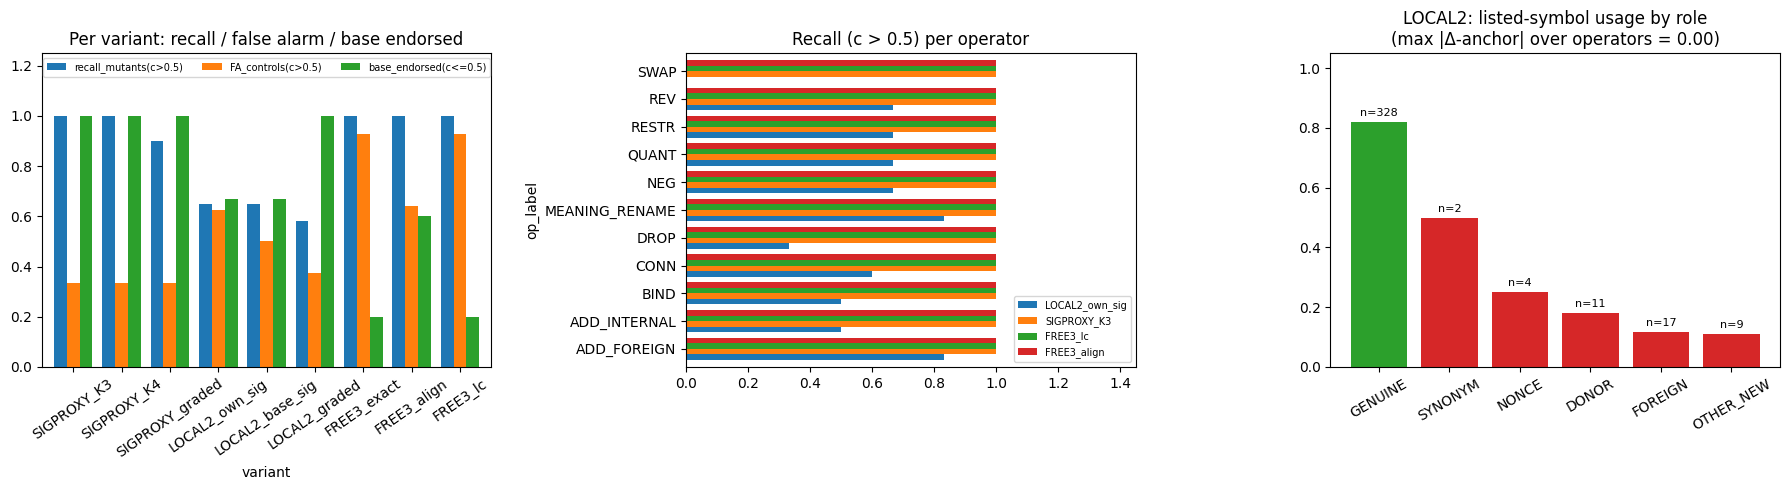

timings: stage-6 scoring 7.4s, typing 25.2s


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1: per-variant recall on mutants vs FA on controls vs base endorsement
plot_df = summary_df.set_index("variant")[["recall_mutants(c>0.5)", "FA_controls(c>0.5)", "base_endorsed(c<=0.5)"]].astype(float)
plot_df.plot.bar(ax=axes[0], rot=35, width=0.8)
axes[0].set_title("Per variant: recall / false alarm / base endorsed")
axes[0].set_ylim(0, 1.25); axes[0].legend(fontsize=7, loc="upper center", ncol=3)

# 2: recall per mutation operator for the main arms
keep = [c for c in ["LOCAL2_own_sig", "SIGPROXY_K3", "FREE3_lc", "FREE3_align"] if c in rec_tab.columns]
rec_tab[keep].drop(index="ALL_MUTANTS", errors="ignore").astype(float).plot.barh(ax=axes[1], width=0.8)
axes[1].set_title("Recall (c > 0.5) per operator"); axes[1].set_xlim(0, 1.45); axes[1].legend(fontsize=7, loc="lower right")

# 3: LOCAL2 anchoring - how often cued peers actually use each kind of listed symbol
role_order = ["GENUINE", "SYNONYM", "NONCE", "DONOR", "FOREIGN", "OTHER_NEW"]
su = loc.get("symbol_usage_by_role") or {}
roles_present = [r_ for r_ in role_order if r_ in su]
if roles_present:
    axes[2].bar(roles_present, [su[r_]["rate"] for r_ in roles_present], color=["tab:green"] + ["tab:red"] * (len(roles_present) - 1))
    for j, r_ in enumerate(roles_present):
        axes[2].text(j, su[r_]["rate"] + 0.02, f"n={su[r_]['n']}", ha="center", fontsize=8)
    dmax = max((abs(d["delta_anchor_rowlevel"] or 0) for d in loc.get("delta_anchor", [])), default=0)
    axes[2].set_title(f"LOCAL2: listed-symbol usage by role\n(max |Δ-anchor| over operators = {dmax:.2f})")
    axes[2].set_ylim(0, 1.05); axes[2].tick_params(axis="x", rotation=30)
else:
    axes[2].text(0.5, 0.5, "no LOCAL2 rows in this subset", ha="center", va="center"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()
print(f"timings: stage-6 scoring {T_SCORE:.1f}s, typing {T_TYPING:.1f}s")

### Reading the results

* **Cueing removes the vocabulary problem.** Uncued FREE3 peers rarely match a correct base exactly (`FREE3_exact` / `FREE3_lc` flag almost everything, bases included), because each family chooses its own names. Given the candidate's symbols, SIGPROXY peers reproduce the correct base exactly, so base endorsement is high and false alarms on equivalence-preserving rewrites (`CONTRAPOSITIVE`, `REORDER_COMMUTE`) are low.
* **Renames need re-cueing.** SIGPROXY peers were cued with the *base's* signature. A `RENAME_SYN` / `RENAME_NONCE` control therefore uses symbols no peer used, and it gets flagged even though its meaning is unchanged. In the artifact, the rename FA is 1.000. Real CSC cues each candidate with its *own* list, which LOCAL2 approximates.
* **Anchoring (LOCAL2).** Small local peers seldom copy foreign, donor or nonce symbols from the list. When they do, their formula still differs from the mutant, so the error is not endorsed. They also often fail to produce 2 parseable formulas, which leaves many rows `csc_insufficient_peers`.
* **Typing.** Once the peer majority shares the candidate's vocabulary, repairing toward it recovers the operator about as well as the oracle (`proxy` vs `oracle` strict accuracy). Toward uncued peers (`free3`), typing mostly fails: either the three peers form no majority (`NO_TARGET`), or their different names make the target unreachable (`NO_REPAIR` / `VOCAB_GAP`).

To reproduce at full scale, run the artifact's `method.py --stage score,typing,analysis` on the full `data/` (and `--stage pilot,peers,...` once there is API budget).